# Estudio comparativo · detección de blanqueo por clasificación de nodos

**Trabajo Fin de Máster** · Detección de patrones estructurados de blanqueo de capitales
mediante una arquitectura híbrida de redes neuronales de grafos (PNA) y potenciación del
gradiente (XGBoost), aplicada al conjunto sintético IBM AMLworld.

## Diseño experimental

Ablación anidada de cuatro modelos:

| # | Modelo | Información que utiliza |
|---|--------|------------------------|
| 1 | XGBoost (sin grafo) | 15 variables tabulares |
| 2 | XGBoost (con grafo) | las 15 tabulares + 16 estructurales explícitas (31) |
| 3 | PNA en solitario | las 33 variables (estructura de la red vía paso de mensajes) |
| 4 | Híbrido PNA + XGBoost | las 31 del modelo 2 + 16 embeddings de la PNA |

El salto **1→2** aísla la aportación de las variables estructurales calculadas *a priori*;
el salto **2→4** aísla la de los embeddings aprendidos por la red neuronal de grafos. El
modelo 3 sirve de referencia de la GNN sin clasificador de árboles.

## Requisitos de ejecución

- Fichero `Transacciones_solo_patrones.csv` en el directorio de trabajo.
- Dependencias del fichero `requirements.txt` adjunto.
- Ejecutar las celdas **de arriba abajo**, sin reinicios intermedios.




---
## 0 · Importaciones y configuración global

In [ ]:
# Ejecutar SOLO si la comprobación de versión de la celda siguiente lo indica.
# Tras instalar, es imprescindible reiniciar el kernel (Kernel → Restart).
# %pip install xgboost==2.1.4

In [1]:
import warnings

import numpy as np
import pandas as pd
import networkx as nx

import torch
import torch.nn.functional as F
from torch_geometric.nn import PNAConv
from torch_geometric.utils import degree as pyg_degree
from torch_geometric.data import Data

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold)
from sklearn.metrics import (classification_report, f1_score,
                             average_precision_score, roc_auc_score)
from scipy.stats import randint, uniform, loguniform

import xgboost as xgb
import shap
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

# --- Comprobación temprana de la versión de XGBoost ---------------------------
# El fallo de SHAP no se manifestaría hasta el último bloque del cuaderno, de modo
# que conviene detectarlo antes de lanzar el entrenamiento completo.
_v = tuple(int(p) for p in xgb.__version__.split('.')[:2])
if _v >= (3, 0):
    raise RuntimeError(
        f"XGBoost {xgb.__version__} detectado. Las versiones >= 3.0 rompen la "
        f"interpretabilidad con SHAP en Python 3.10.\n"
        f"Ejecute la celda anterior (%pip install xgboost==2.1.4) y reinicie el kernel."
    )

print(f"XGBoost {xgb.__version__} · SHAP {shap.__version__} · Torch {torch.__version__}")

XGBoost 2.1.4 · SHAP 0.49.1 · Torch 2.12.0+cpu


In [4]:
# --- Parámetros del experimento -----------------------------------------------
RUTA = r"Transacciones_solo_patrones.csv"  # <-- ajuste la ruta si procede

TRAIN_INI, TRAIN_FIN = 1, 3     # días 1-3 → entrenamiento
TEST_INI,  TEST_FIN  = 4, 6     # días 4-6 → prueba (partición temporal)

SEED = 42                       # semilla única para toda la reproducibilidad
torch.manual_seed(SEED)
np.random.seed(SEED)

# Variables excluidas de las matrices de XGBoost por la ablación previa
# (introducen atajos o penalizan la dispersión). La PNA sí las recibe.
EXCLUIR_XGB = ['Total_Neighbors', 'Total_Paid_EUR']

# Hiperparámetros de la red PNA
PNA_OCULTA   = 32     # dimensión de la capa oculta
PNA_EMBED    = 16     # dimensión del embedding final (nº de columnas emb_i)
PNA_EPOCAS_3 = 80     # épocas del modelo 3 (con máscara de validación)
PNA_EPOCAS_4 = 120    # épocas del modelo 4 (sobre todo el train)
PNA_LR       = 0.01   # tasa de aprendizaje del optimizador Adam
PNA_DROPOUT  = 0.3

# Búsqueda de hiperparámetros de XGBoost
N_ITER_BUSQUEDA = 40  # combinaciones evaluadas por RandomizedSearchCV
N_FOLDS_CV      = 3   # particiones de la validación cruzada estratificada

---
## 1 · Carga y filtrado del conjunto de datos

Se eliminan las transacciones de una cuenta consigo misma: no aportan información
estructural y distorsionan el cálculo de los grados del grafo.

In [5]:
df = pd.read_csv(RUTA)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Account'] != df['Account.1']].copy()

# Diccionario de días del conjunto AMLworld (el día 1 es el 1 de septiembre).
DIA = {i: pd.Timestamp('2022-09-01') + pd.Timedelta(days=i - 1) for i in range(1, 19)}
ini = lambda i: DIA[i].strftime('%Y-%m-%d 00:00:00')
fin = lambda i: DIA[i].strftime('%Y-%m-%d 23:59:59')

print(f"Transacciones totales: {len(df):,}")

Transacciones totales: 4,487,133


---
## 2 · Detector de ciclos temporales

Un ciclo constituye indicio de blanqueo cuando el dinero regresa al origen siguiendo una
secuencia temporal coherente y conservando aproximadamente su importe. Se exige, por tanto:

1. longitud entre 3 y 8 nodos;
2. marcas de tiempo crecientes a lo largo del recorrido;
3. que el importe final se sitúe entre el 75 % y el 125 % del inicial (margen para
   comisiones y variaciones de cambio).



In [6]:
def ciclos_accounts(d):
    """Devuelve el conjunto de cuentas que participan en algún ciclo temporal válido.

    Parámetros
    ----------
    d : pandas.DataFrame
        Transacciones de la partición (train o test).

    Devuelve
    --------
    set
        Identificadores de las cuentas implicadas en al menos un ciclo válido.
    """
    # Grafo dirigido en el que cada arista almacena la lista de transacciones
    # (marca de tiempo, importe) entre ese par de cuentas.
    G = nx.DiGraph()
    for _, r in d.iterrows():
        u, v = r['Account'], r['Account.1']
        t, a = r['Timestamp'], float(r['Amount_Paid_EUR'])
        if G.has_edge(u, v):
            G[u][v]['txs'].append((t, a))
        else:
            G.add_edge(u, v, txs=[(t, a)])

    accs = set()
    for ciclo in nx.simple_cycles(G, length_bound=8):
        L = len(ciclo)
        if L < 3:
            continue

        aristas = [(ciclo[i], ciclo[(i + 1) % L]) for i in range(L)]

        def buscar(orden):
            """Busca una secuencia de transacciones temporalmente creciente."""
            seq, tp = [], None
            for (u, v) in orden:
                el = None
                # Primera transacción posterior (o igual) a la anterior del recorrido.
                for (t, a) in sorted(G[u][v]['txs']):
                    if tp is None or t >= tp:
                        el = (t, a)
                        break
                if el is None:
                    return None      # el ciclo se rompe: no hay continuidad temporal
                seq.append(el)
                tp = el[0]
            return seq

        # El ciclo puede empezar en cualquiera de sus nodos: se prueban las rotaciones.
        for r0 in range(L):
            seq = buscar(aristas[r0:] + aristas[:r0])
            if seq:
                ai, af = seq[0][1], seq[-1][1]     # importe inicial y final
                if ai > 0 and 0.75 <= af / ai <= 1.25:
                    accs.update(ciclo)
                    break
    return accs

---
## 3 · Construcción de la tabla de nodos

Todos los modelos parten de **la misma tabla de nodos**; cada uno toma después su
subconjunto de columnas. Esta función unificada evita las discrepancias que surgían al
construir por separado el bloque tabular y el bloque de grafo.



In [7]:
def construir_nodos(dd):
    """Construye el perfil de variables de cada cuenta a partir de sus transacciones.

    Parámetros
    ----------
    dd : pandas.DataFrame
        Transacciones de la partición.

    Devuelve
    --------
    pandas.DataFrame
        Una fila por cuenta con 33 variables más el identificador y la etiqueta.
    """
    d = dd[dd['Account'] != dd['Account.1']].copy().reset_index(drop=True)

    # --- Grados y volúmenes ---------------------------------------------------
    # Out_Degree / In_Degree cuentan CONTRAPARTES ÚNICAS, no transacciones.
    out_s = d.groupby('Account').agg(
        Out_Degree=('Account.1', 'nunique'),
        Total_Paid_EUR=('Amount_Paid_EUR', 'sum')
    ).reset_index().rename(columns={'Account': 'acc'})

    in_s = d.groupby('Account.1').agg(
        In_Degree=('Account', 'nunique'),
        Total_Received_EUR=('Amount_Received_EUR', 'sum')
    ).reset_index().rename(columns={'Account.1': 'acc'})

    nodos = pd.merge(out_s, in_s, on='acc', how='outer').fillna(0)
    nodos['Total_EUR'] = nodos['Total_Paid_EUR'] + nodos['Total_Received_EUR']

    # --- Número total de transacciones (con repetición) -----------------------
    # Debe calcularse ANTES de Media_EUR, que lo usa como denominador.
    cnt = pd.concat([d['Account'], d['Account.1']]).value_counts()
    nodos['N_Tx_Total'] = nodos['acc'].map(cnt).fillna(0)

    # Media_EUR: importe medio POR TRANSACCIÓN REAL.
    nodos['Media_EUR'] = nodos['Total_EUR'] / nodos['N_Tx_Total'].replace(0, 1)

    # Ratio de flujo: valores muy altos señalan cuentas sumidero; muy bajos,
    # cuentas dispersoras.
    nodos['Ratio_Flujo'] = nodos['Total_Received_EUR'] / (nodos['Total_Paid_EUR'] + 1e-5)

    # --- Diversidad de formatos de pago y de divisas ---------------------------
    # La diversificación artificial de canales es un indicio de estructuración.
    o = d[['Account', 'Payment Format', 'Payment Currency']].rename(
        columns={'Account': 'acc', 'Payment Currency': 'cur'})
    de = d[['Account.1', 'Payment Format', 'Receiving Currency']].rename(
        columns={'Account.1': 'acc', 'Receiving Currency': 'cur'})
    sides = pd.concat([o, de], ignore_index=True)
    nodos['Unique_Formats'] = nodos['acc'].map(
        sides.groupby('acc')['Payment Format'].nunique()).fillna(0)
    nodos['Unique_Currencies'] = nodos['acc'].map(
        sides.groupby('acc')['cur'].nunique()).fillna(0)

    # --- Estadísticos de importe (en euros normalizados) -----------------------
    ao = d[['Account', 'Amount_Paid_EUR']].rename(
        columns={'Account': 'acc', 'Amount_Paid_EUR': 'amt'})
    ade = d[['Account.1', 'Amount_Received_EUR']].rename(
        columns={'Account.1': 'acc', 'Amount_Received_EUR': 'amt'})
    amts = pd.concat([ao, ade], ignore_index=True).groupby('acc')['amt']
    nodos['Amt_Max'] = nodos['acc'].map(amts.max()).fillna(0)
    nodos['Amt_Min'] = nodos['acc'].map(amts.min()).fillna(0)
    nodos['Amt_Std'] = nodos['acc'].map(amts.std()).fillna(0)
    nodos['Amt_Mean'] = nodos['acc'].map(amts.mean()).fillna(0)

    # --- Bancos contraparte y fracción de operaciones interbancarias -----------
    bo = d[['Account', 'To Bank']].rename(columns={'Account': 'acc', 'To Bank': 'bank'})
    bde = d[['Account.1', 'From Bank']].rename(
        columns={'Account.1': 'acc', 'From Bank': 'bank'})
    banks = pd.concat([bo, bde], ignore_index=True)
    nodos['N_Banks_Counterparty'] = nodos['acc'].map(
        banks.groupby('acc')['bank'].nunique()).fillna(0)

    ibo = d[['Account', 'Distinto_banco']].rename(columns={'Account': 'acc'})
    ibd = d[['Account.1', 'Distinto_banco']].rename(columns={'Account.1': 'acc'})
    nodos['Frac_InterBanco'] = nodos['acc'].map(
        pd.concat([ibo, ibd], ignore_index=True).groupby('acc')['Distinto_banco'].mean()
    ).fillna(0)

    # --- Métricas temporales ---------------------------------------------------
    # Burstiness (estadístico B de Goh y Barabási): mide si la actividad se
    # concentra en ráfagas (valores próximos a 1) o es regular (próximos a -1).
    # LIMITACIÓN: las cuentas con una sola transacción no tienen desviación típica
    # definida; se les asigna 0 mediante fillna(0), valor que coincide con el de
    # una distribución exactamente poissoniana.
    to = d[['Account', 'Timestamp']].rename(columns={'Account': 'acc'})
    tde = d[['Account.1', 'Timestamp']].rename(columns={'Account.1': 'acc'})
    tt = pd.concat([to, tde], ignore_index=True).sort_values(['acc', 'Timestamp'])
    tt['dt'] = tt.groupby('acc')['Timestamp'].diff().dt.total_seconds()
    gdt = tt.groupby('acc')['dt']
    mu, sg = gdt.mean(), gdt.std()
    nodos['Burstiness'] = nodos['acc'].map((sg - mu) / (sg + mu + 1e-9)).fillna(0)
    nodos['Mean_DeltaT'] = nodos['acc'].map(mu).fillna(0)

    # --- Métricas globales de grafo --------------------------------------------
    G = nx.from_pandas_edgelist(d, 'Account', 'Account.1',
                                edge_attr='Amount_Paid_EUR',
                                create_using=nx.DiGraph())
    Gu = G.to_undirected()
    nodos['PageRank'] = nodos['acc'].map(
        nx.pagerank(G, weight='Amount_Paid_EUR', max_iter=100)).fillna(0)
    nodos['Total_Neighbors'] = nodos['acc'].map(dict(Gu.degree())).fillna(0)
    nodos['Clustering'] = nodos['acc'].map(
        nx.clustering(Gu, weight='Amount_Paid_EUR')).fillna(0)

    # --- Agregaciones de vecindario (información de segundo orden) -------------
    # Resumen de los grados de los vecinos: permite a un modelo tabular acceder a
    # información situada a dos saltos, que es precisamente lo que la GNN aprende
    # de forma automática mediante el paso de mensajes.
    look = nodos.set_index('acc')[['In_Degree', 'Out_Degree', 'Total_Neighbors']]
    e1 = d[['Account', 'Account.1']].rename(columns={'Account': 'u', 'Account.1': 'v'})
    e2 = d[['Account', 'Account.1']].rename(columns={'Account.1': 'u', 'Account': 'v'})
    eud = pd.concat([e1, e2], ignore_index=True).merge(
        look, left_on='v', right_index=True, how='left')
    agg = eud.groupby('u').agg(
        MaxNbr_InDegree=('In_Degree', 'max'),
        MaxNbr_OutDegree=('Out_Degree', 'max'),
        MaxNbr_Degree=('Total_Neighbors', 'max'),
        MeanNbr_InDegree=('In_Degree', 'mean'),
        MeanNbr_OutDegree=('Out_Degree', 'mean'),
        MeanNbr_Degree=('Total_Neighbors', 'mean'),
        StdNbr_InDegree=('In_Degree', 'std'),
        StdNbr_OutDegree=('Out_Degree', 'std'),
        StdNbr_Degree=('Total_Neighbors', 'std')).reset_index()
    nodos = nodos.merge(agg, left_on='acc', right_on='u', how='left') \
                 .drop(columns='u').fillna(0)

    # Porcentaje de vecinos para los que esta cuenta es su ÚNICA contraparte:
    # firma característica de las cuentas mula en estructuras de dispersión.
    eud_u = eud.drop_duplicates(subset=['u', 'v'])
    excl = (eud_u.assign(ex=(eud_u['Total_Neighbors'] == 1).astype(int))
                 .groupby('u')['ex'].mean())
    nodos['PctNeighbors_Exclusive'] = nodos['acc'].map(excl).fillna(0)

    # Reciprocidad: fracción de contrapartes con las que existe ida y vuelta.
    out_n = d.groupby('Account')['Account.1'].apply(set).to_dict()
    in_n = d.groupby('Account.1')['Account'].apply(set).to_dict()
    rec = []
    for acc in nodos['acc']:
        o_set = out_n.get(acc, set())
        i_set = in_n.get(acc, set())
        uni = o_set | i_set
        rec.append(len(o_set & i_set) / len(uni) if uni else 0.0)
    nodos['Reciprocity'] = rec

    # Pertenencia a un ciclo temporal válido (indicador binario).
    accs_ciclo = ciclos_accounts(d)
    nodos['En_Ciclo'] = nodos['acc'].isin(accs_ciclo).astype(int)

    # --- Etiqueta --------------------------------------------------------------
    # Una cuenta se considera fraudulenta si participa en al menos una transacción
    # marcada como patrón de blanqueo estructuralmente detectable.
    fraude_acc = set(dd.loc[dd['Is Laundering'] == 1, 'Account']) | \
                 set(dd.loc[dd['Is Laundering'] == 1, 'Account.1'])
    nodos['label'] = nodos['acc'].isin(fraude_acc).astype(int)

    return nodos

---
## 4 · Particiones temporales y subconjuntos de variables

La partición es **temporal** (días 1-3 frente a días 4-6), no aleatoria: reproduce la
situación real en que el modelo debe generalizar a operativa futura.

- **`VARS_TABULARES`** (15): variables no estructurales → modelo 1.
- **`VARS_CON_GRAFO`** (31): todas salvo `Total_Neighbors` y `Total_Paid_EUR` → modelo 2
  y bloque explícito del modelo 4.
- **`feat_cols`** (33): todas → entrada de la PNA (modelos 3 y 4).

> Esta celda puede tardar varios minutos: la detección de ciclos recorre el grafo completo
> de cada partición.

In [8]:
df_tr = df[(df['Timestamp'] >= ini(TRAIN_INI)) & (df['Timestamp'] <= fin(TRAIN_FIN))].copy()
df_te = df[(df['Timestamp'] >= ini(TEST_INI)) & (df['Timestamp'] <= fin(TEST_FIN))].copy()

nodos_tr = construir_nodos(df_tr)
nodos_te = construir_nodos(df_te)
ytr = nodos_tr['label'].values
yte = nodos_te['label'].values

# Las 33 variables completas (entrada de la PNA).
feat_cols = [c for c in nodos_tr.columns if c not in ('acc', 'label')]

# Bloque tabular (15): variables no estructurales, sin Total_Paid_EUR.
VARS_TABULARES = ['Total_Received_EUR', 'Total_EUR', 'Media_EUR', 'Ratio_Flujo',
                  'N_Tx_Total', 'Unique_Formats', 'Unique_Currencies',
                  'Amt_Max', 'Amt_Min', 'Amt_Std', 'Amt_Mean',
                  'N_Banks_Counterparty', 'Frac_InterBanco', 'Burstiness', 'Mean_DeltaT']

# Bloque con grafo (31): todas salvo las dos excluidas por la ablación.
VARS_CON_GRAFO = [c for c in feat_cols if c not in EXCLUIR_XGB]

# Estructurales explícitas (16): la diferencia entre los dos bloques anteriores.
VARS_ESTRUCTURALES = [c for c in VARS_CON_GRAFO if c not in VARS_TABULARES]

print(f"PNA: {len(feat_cols)} variables | tabulares: {len(VARS_TABULARES)} "
      f"| con grafo: {len(VARS_CON_GRAFO)} | estructurales: {len(VARS_ESTRUCTURALES)}")
print("Estructurales explícitas:", VARS_ESTRUCTURALES)
print(f"TRAIN: {len(nodos_tr):,} cuentas | fraude {int(ytr.sum())} ({ytr.mean()*100:.3f}%)")
print(f"TEST : {len(nodos_te):,} cuentas | fraude {int(yte.sum())} ({yte.mean()*100:.3f}%)")

PNA: 33 variables | tabulares: 15 | con grafo: 31 | estructurales: 16
Estructurales explícitas: ['Out_Degree', 'In_Degree', 'PageRank', 'Clustering', 'MaxNbr_InDegree', 'MaxNbr_OutDegree', 'MaxNbr_Degree', 'MeanNbr_InDegree', 'MeanNbr_OutDegree', 'MeanNbr_Degree', 'StdNbr_InDegree', 'StdNbr_OutDegree', 'StdNbr_Degree', 'PctNeighbors_Exclusive', 'Reciprocity', 'En_Ciclo']
TRAIN: 394,999 cuentas | fraude 601 (0.152%)
TEST : 244,221 cuentas | fraude 1015 (0.416%)


---
## 5 · Protocolo de evaluación común

El umbral de decisión **no** se elige sobre el conjunto de prueba: se selecciona
maximizando el F1 sobre una validación interna del entrenamiento (25 %, estratificada),
con un modelo ajustado sin esas cuentas. Solo después se reentrena con todo el train y se
evalúa el test una única vez.

La métrica principal es el **PR-AUC**: con una tasa de positivos en torno al 0,04 %, el
ROC-AUC resulta artificialmente alto y poco discriminante, y la exactitud carece por
completo de valor informativo.



In [9]:
resultados = {}


def evaluar(nombre, clf, Xtr, Xte, ytr, yte):
    """Aplica el protocolo común de umbral y evaluación a un clasificador XGBoost.

    Parámetros
    ----------
    nombre : str
        Rótulo del modelo en la tabla comparativa.
    clf : xgboost.XGBClassifier
        Clasificador ya configurado con sus hiperparámetros.
    Xtr, Xte : pandas.DataFrame
        Matrices de entrenamiento y prueba.
    ytr, yte : numpy.ndarray
        Etiquetas correspondientes.

    Devuelve
    --------
    xgboost.XGBClassifier
        El clasificador reentrenado sobre todo el conjunto de entrenamiento.
    """
    # Partición interna: ajuste (75%) y validación para el umbral (25%).
    Xf, Xv, yf, yv = train_test_split(Xtr, ytr, test_size=0.25,
                                      stratify=ytr, random_state=SEED)
    clf.fit(Xf, yf)                        # ajuste SIN las cuentas de validación
    pv = clf.predict_proba(Xv)[:, 1]

    # Barrido de umbrales maximizando el F1 de la clase minoritaria.
    umbral, mejor = 0.5, 0
    for u in np.linspace(0.01, 0.99, 99):
        f = f1_score(yv, (pv >= u).astype(int), zero_division=0)
        if f > mejor:
            mejor, umbral = f, u

    clf.fit(Xtr, ytr)                      # reentrenamiento con todo el train
    pte = clf.predict_proba(Xte)[:, 1]
    pred = (pte >= umbral).astype(int)

    roc = roc_auc_score(yte, pte)
    pr = average_precision_score(yte, pte)
    f1m = f1_score(yte, pred, zero_division=0)

    print(f"===== {nombre} =====")
    print(f"umbral (validación) = {umbral:.2f}")
    print(f"ROC-AUC = {roc:.4f} | PR-AUC = {pr:.4f} | F1 minoritaria = {f1m:.4f}")
    print(classification_report(yte, pred,
                                target_names=['Cuenta limpia', 'Cuenta fraude'],
                                zero_division=0))

    resultados[nombre] = {'ROC-AUC': roc, 'PR-AUC': pr, 'F1 minoritaria': f1m}
    return clf


# Espacio de búsqueda ÚNICO para todos los XGBoost del estudio: garantiza que las
# diferencias entre modelos procedan de las variables, no del ajuste.
ESPACIO_XGB = {
    'n_estimators':     randint(200, 800),
    'max_depth':        randint(3, 11),
    'learning_rate':    loguniform(1e-2, 3e-1),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma':            uniform(0, 5),
    'reg_lambda':       loguniform(1e-2, 1e2),
    'reg_alpha':        loguniform(1e-3, 1e1),
}


def buscar_xgb(Xtr, ytr):
    """Busca hiperparámetros por muestreo aleatorio maximizando el PR-AUC.

    El desbalanceo se compensa con `scale_pos_weight` (cociente entre negativos y
    positivos). La métrica interna es 'aucpr', coherente con el criterio externo
    'average_precision' de la validación cruzada.
    """
    spw = (len(ytr) - ytr.sum()) / max(ytr.sum(), 1)

    base = xgb.XGBClassifier(tree_method='hist',
                             eval_metric='aucpr',
                             scale_pos_weight=spw,
                             random_state=SEED)

    busq = RandomizedSearchCV(base, ESPACIO_XGB,
                              n_iter=N_ITER_BUSQUEDA,
                              scoring='average_precision',
                              cv=StratifiedKFold(n_splits=N_FOLDS_CV, shuffle=True,
                                                 random_state=SEED),
                              n_jobs=-1, random_state=SEED, verbose=1)
    busq.fit(Xtr, ytr)

    print("Mejores hiperparámetros:", busq.best_params_)
    print(f"PR-AUC (CV train): {busq.best_score_:.4f}")
    return busq.best_estimator_

---
## 6 · Modelo 1 · XGBoost sin información de grafo

Línea base: potenciación del gradiente sobre las 15 variables tabulares, sin acceso alguno
a la topología de la red. Cuantifica cuánto puede detectarse analizando cada cuenta de
forma aislada. No requiere estandarización.

In [10]:
Xtr_1 = nodos_tr[VARS_TABULARES]
Xte_1 = nodos_te[VARS_TABULARES]

clf_1 = buscar_xgb(Xtr_1, ytr)
clf_1 = evaluar("1 · XGBoost (sin grafo)", clf_1, Xtr_1, Xte_1, ytr, yte)

imp1 = (pd.DataFrame({'Variable': Xtr_1.columns,
                      'Importancia': clf_1.feature_importances_})
        .sort_values('Importancia', ascending=False).head(10))
print("\nTop 10 variables:")
print(imp1.to_string(index=False))

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejores hiperparámetros: {'colsample_bytree': np.float64(0.9343920482048823), 'gamma': np.float64(3.47987103046849), 'learning_rate': np.float64(0.04018584329485903), 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 295, 'reg_alpha': np.float64(0.15736446109772145), 'reg_lambda': np.float64(7.217448452444785), 'subsample': np.float64(0.8640789506870925)}
PR-AUC (CV train): 0.0974
===== 1 · XGBoost (sin grafo) =====
umbral (validación) = 0.96
ROC-AUC = 0.9226 | PR-AUC = 0.2538 | F1 minoritaria = 0.2113
               precision    recall  f1-score   support

Cuenta limpia       1.00      1.00      1.00    243206
Cuenta fraude       0.68      0.13      0.21      1015

     accuracy                           1.00    244221
    macro avg       0.84      0.56      0.60    244221
 weighted avg       1.00      1.00      0.99    244221


Top 10 variables:
            Variable  Importancia
             Amt_Max     0.220567
   Un

---
## 7 · Modelo 2 · XGBoost con variables estructurales explícitas

Mismo algoritmo y mismo protocolo, añadiendo las 16 métricas de grafo calculadas *a
priori* (grados, PageRank, clustering, agregaciones de vecindario, reciprocidad,
pertenencia a ciclo). La distancia respecto al modelo 1 mide la aportación de la
estructura cuando se expresa mediante ingeniería de variables manual.

In [11]:
Xtr_2 = nodos_tr[VARS_CON_GRAFO]
Xte_2 = nodos_te[VARS_CON_GRAFO]

clf_2 = buscar_xgb(Xtr_2, ytr)
clf_2 = evaluar("2 · XGBoost (con grafo)", clf_2, Xtr_2, Xte_2, ytr, yte)

imp2 = (pd.DataFrame({'Variable': Xtr_2.columns,
                      'Importancia': clf_2.feature_importances_})
        .sort_values('Importancia', ascending=False).head(10))
print("\nTop 10 variables:")
print(imp2.to_string(index=False))

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejores hiperparámetros: {'colsample_bytree': np.float64(0.8417669517111269), 'gamma': np.float64(2.6992054565083654), 'learning_rate': np.float64(0.019950144748611585), 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 442, 'reg_alpha': np.float64(0.00441453687649448), 'reg_lambda': np.float64(52.334804885400885), 'subsample': np.float64(0.9232481518257668)}
PR-AUC (CV train): 0.1177
===== 2 · XGBoost (con grafo) =====
umbral (validación) = 0.96
ROC-AUC = 0.9346 | PR-AUC = 0.2943 | F1 minoritaria = 0.1972
               precision    recall  f1-score   support

Cuenta limpia       1.00      1.00      1.00    243206
Cuenta fraude       0.81      0.11      0.20      1015

     accuracy                           1.00    244221
    macro avg       0.90      0.56      0.60    244221
 weighted avg       1.00      1.00      0.99    244221


Top 10 variables:
            Variable  Importancia
   Unique_Currencies     0.160599
 

---
## 8 · Construcción de los grafos de PyTorch Geometric

El `StandardScaler` se ajusta **únicamente** sobre el conjunto de entrenamiento y se aplica
después al de prueba, para no filtrar información del futuro.

Para poder elegir el umbral de decisión sin tocar el test, se aparta además un 25 % de las
cuentas de entrenamiento como validación: la pérdida solo se calculará sobre el 75 %
restante.

In [12]:
scaler = StandardScaler().fit(nodos_tr[feat_cols].values)


def grafo_pyg(nodos, dd, feat_cols, scaler):
    """Convierte la tabla de nodos y sus transacciones en un objeto Data de PyG."""
    cuentas = nodos['acc'].values
    mapeo = {c: i for i, c in enumerate(cuentas)}       # cuenta → índice del tensor

    d = dd[dd['Account'] != dd['Account.1']]
    e = d[d['Account'].isin(mapeo) & d['Account.1'].isin(mapeo)]

    ei = torch.tensor(np.array([e['Account'].map(mapeo).values,
                                e['Account.1'].map(mapeo).values]), dtype=torch.long)

    Xn = scaler.transform(nodos[feat_cols].values)

    return Data(x=torch.tensor(Xn, dtype=torch.float),
                edge_index=ei,
                y=torch.tensor(nodos['label'].values, dtype=torch.float)), cuentas


g_tr, cuentas_tr = grafo_pyg(nodos_tr, df_tr, feat_cols, scaler)
g_te, cuentas_te = grafo_pyg(nodos_te, df_te, feat_cols, scaler)

print(f"Grafo train: {g_tr.x.shape[0]:,} nodos, {g_tr.edge_index.shape[1]:,} aristas")
print(f"Grafo test : {g_te.x.shape[0]:,} nodos, {g_te.edge_index.shape[1]:,} aristas")

# Máscaras de ajuste y validación.
idx = np.arange(len(nodos_tr))
idx_fit, idx_val = train_test_split(idx, test_size=0.25, random_state=SEED,
                                    stratify=nodos_tr['label'].values)
mask_fit = torch.zeros(len(idx), dtype=torch.bool); mask_fit[idx_fit] = True
mask_val = torch.zeros(len(idx), dtype=torch.bool); mask_val[idx_val] = True

print(f"Nodos para ajuste: {mask_fit.sum().item():,} | "
      f"para validación: {mask_val.sum().item():,}")

Grafo train: 394,999 nodos, 1,549,530 aristas
Grafo test : 244,221 nodos, 1,147,005 aristas
Nodos para ajuste: 296,249 | para validación: 98,750


---
## 9 · Arquitectura de la red (PNA · *Principal Neighbourhood Aggregation*)

Dos capas `PNAConv` con agregadores `mean/min/max/std` y escaladores
`identity/amplification/attenuation`, seguidas de una capa lineal que emite el logit de
fraude.

La elección de **dos** capas responde a un compromiso: una sola alcanzaría únicamente los
vecinos inmediatos, mientras que tres o más provocarían sobresuavizado
(*over-smoothing*), homogeneizando las representaciones de nodos estructuralmente
distintos.

El histograma de grados que necesitan los escaladores se calcula **solo con el grafo de
train**, para evitar fugas de información.

In [13]:
def histograma_grados(edge_index, num_nodes):
    """Histograma de grados de entrada, necesario para los escaladores de la PNA."""
    d = pyg_degree(edge_index[1], num_nodes=num_nodes, dtype=torch.long)
    deg = torch.zeros(int(d.max()) + 1, dtype=torch.long)
    deg += torch.bincount(d, minlength=deg.numel())
    return deg


class NodePNA(torch.nn.Module):
    """Red de clasificación de nodos con dos capas de agregación PNA.

    El método forward devuelve una tupla (logit, embedding): el logit alimenta la
    evaluación del modelo 3, y el embedding de 16 dimensiones constituye la entrada
    adicional de XGBoost en el modelo híbrido.
    """

    def __init__(self, i, h, e, deg):
        super().__init__()
        aggregators = ['mean', 'min', 'max', 'std']
        scalers = ['identity', 'amplification', 'attenuation']
        self.c1 = PNAConv(i, h, aggregators=aggregators, scalers=scalers,
                          deg=deg, towers=1, divide_input=False)
        self.c2 = PNAConv(h, e, aggregators=aggregators, scalers=scalers,
                          deg=deg, towers=1, divide_input=False)
        self.clf = torch.nn.Linear(e, 1)

    def forward(self, x, ei):
        h = F.relu(self.c1(x, ei))
        h = F.dropout(h, PNA_DROPOUT, self.training)
        emb = F.relu(self.c2(h, ei))
        return self.clf(emb), emb

---
## 10 · Modelo 3 · PNA en solitario

La red recibe las 33 variables (incluidas `Total_Neighbors` y `Total_Paid_EUR`, conforme a
la decisión metodológica adoptada) y aprende la estructura mediante paso de mensajes.

El paso de mensajes recorre **todo** el grafo —necesario para captar la estructura
completa—, pero la pérdida se calcula solo sobre la máscara de ajuste: así el umbral
posterior se elige sobre nodos que no han intervenido en la optimización.

In [14]:
y_fit = g_tr.y[mask_fit]
n_pos = int(y_fit.sum())
n_neg = int(mask_fit.sum()) - n_pos

deg_hist = histograma_grados(g_tr.edge_index, g_tr.x.shape[0])

modelo = NodePNA(g_tr.x.shape[1], PNA_OCULTA, PNA_EMBED, deg_hist)
opt = torch.optim.Adam(modelo.parameters(), lr=PNA_LR)

# La ponderación positiva compensa el desbalanceo extremo dentro de la pérdida.
crit = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_neg / max(n_pos, 1)]))

modelo.train()
for ep in range(PNA_EPOCAS_3):
    opt.zero_grad()
    lo, _ = modelo(g_tr.x, g_tr.edge_index)
    loss = crit(lo.squeeze()[mask_fit], y_fit)   # pérdida SOLO sobre la máscara de ajuste
    loss.backward()
    opt.step()
    if ep % 10 == 0:
        print(f"epoch {ep:>3} | BCE {loss.item():.4f}")

epoch   0 | BCE 1.4345
epoch  10 | BCE 1.4062
epoch  20 | BCE 0.9827
epoch  30 | BCE 0.9588
epoch  40 | BCE 0.8378
epoch  50 | BCE 0.8162
epoch  60 | BCE 0.7514
epoch  70 | BCE 0.7085


### Umbral en validación y evaluación en test

In [15]:
modelo.eval()
with torch.no_grad():
    lo_tr, _ = modelo(g_tr.x, g_tr.edge_index)
    lo_te, _ = modelo(g_te.x, g_te.edge_index)

p_tr = torch.sigmoid(lo_tr.squeeze()).numpy()
p_te = torch.sigmoid(lo_te.squeeze()).numpy()

# Umbral por F1 sobre la máscara de validación.
yv = g_tr.y[mask_val].numpy()
pv = p_tr[mask_val.numpy()]

umbral, mejor = 0.5, 0
for u in np.linspace(0.01, 0.99, 99):
    f = f1_score(yv, (pv >= u).astype(int), zero_division=0)
    if f > mejor:
        mejor, umbral = f, u

pred = (p_te >= umbral).astype(int)

print(f"===== 3 · PNA (solo) · test días {TEST_INI}-{TEST_FIN} =====")
print(f"umbral (validación) = {umbral:.2f}")
print(f"ROC-AUC = {roc_auc_score(yte, p_te):.4f} | "
      f"PR-AUC = {average_precision_score(yte, p_te):.4f} | "
      f"F1 minoritaria = {f1_score(yte, pred, zero_division=0):.4f}")
print(classification_report(yte, pred,
                            target_names=['Cuenta limpia', 'Cuenta fraude'],
                            zero_division=0))

resultados["3 · PNA (solo)"] = {
    'ROC-AUC': roc_auc_score(yte, p_te),
    'PR-AUC': average_precision_score(yte, p_te),
    'F1 minoritaria': f1_score(yte, pred, zero_division=0)}

===== 3 · PNA (solo) · test días 4-6 =====
umbral (validación) = 0.99
ROC-AUC = 0.8446 | PR-AUC = 0.2615 | F1 minoritaria = 0.2772
               precision    recall  f1-score   support

Cuenta limpia       1.00      1.00      1.00    243206
Cuenta fraude       0.30      0.26      0.28      1015

     accuracy                           0.99    244221
    macro avg       0.65      0.63      0.64    244221
 weighted avg       0.99      0.99      0.99    244221



### Lectura de los resultados

Este resultado es la referencia de la **GNN sin clasificador de árboles**: la comparación
con el modelo híbrido medirá cuánto aporta sustituir la capa lineal final por un
clasificador no lineal que además recibe las variables tabulares y de grafo originales.

---
## 11 · Modelo 4 · Híbrido PNA + XGBoost

Se entrena una **nueva** red sobre todo el conjunto de entrenamiento (sin máscara, puesto
que aquí el umbral lo gestiona la función `evaluar` con su propia validación interna), se
extraen sus embeddings de 16 dimensiones y XGBoost los combina con las 31 variables del
modelo 2.

La matriz resultante es exactamente la del modelo 2 **más los 16 embeddings**, de modo que
la diferencia de rendimiento entre ambos aísla limpiamente la aportación de la red
neuronal de grafos. Los embeddings del test se obtienen propagando sobre el **grafo de
test**: la red aplica lo aprendido a una topología que no ha visto nunca.

In [16]:
torch.manual_seed(SEED)

n_pos_h = int(g_tr.y.sum())
n_neg_h = len(g_tr.y) - n_pos_h

modelo_h = NodePNA(g_tr.x.shape[1], PNA_OCULTA, PNA_EMBED, deg_hist)
opt_h = torch.optim.Adam(modelo_h.parameters(), lr=PNA_LR)
crit_h = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_neg_h / max(n_pos_h, 1)]))

modelo_h.train()
for ep in range(PNA_EPOCAS_4):
    opt_h.zero_grad()
    lo, _ = modelo_h(g_tr.x, g_tr.edge_index)
    loss = crit_h(lo.squeeze(), g_tr.y)
    loss.backward()
    opt_h.step()
    if ep % 20 == 0:
        print(f"epoch {ep:>3} | BCE {loss.item():.4f}")

# Extracción de embeddings.
modelo_h.eval()
with torch.no_grad():
    _, emb_tr = modelo_h(g_tr.x, g_tr.edge_index)
    _, emb_te = modelo_h(g_te.x, g_te.edge_index)


def matriz(nodos, emb):
    """Concatena las 31 variables explícitas con los 16 embeddings de la PNA."""
    e = pd.DataFrame(emb.numpy(), columns=[f'emb_{i}' for i in range(emb.shape[1])])
    return pd.concat([nodos[VARS_CON_GRAFO].reset_index(drop=True), e], axis=1)


Xtr = matriz(nodos_tr, emb_tr)
Xte = matriz(nodos_te, emb_te)
# Alineación defensiva de columnas: garantiza el mismo orden en train y test.
Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

print(f"Matriz híbrida: {Xtr.shape[1]} columnas "
      f"({len(VARS_CON_GRAFO)} variables + {PNA_EMBED} embeddings)")

clf = buscar_xgb(Xtr, ytr)
clf = evaluar("4 · Híbrido PNA+XGBoost", clf, Xtr, Xte, ytr, yte)
# 'clf' y 'Xte' quedan disponibles para el análisis SHAP.

epoch   0 | BCE 1.4341
epoch  20 | BCE 0.9703
epoch  40 | BCE 0.8278
epoch  60 | BCE 0.7694
epoch  80 | BCE 0.6769
epoch 100 | BCE 0.6514
Matriz híbrida: 47 columnas (31 variables + 16 embeddings)
Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejores hiperparámetros: {'colsample_bytree': np.float64(0.8417669517111269), 'gamma': np.float64(2.6992054565083654), 'learning_rate': np.float64(0.019950144748611585), 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 442, 'reg_alpha': np.float64(0.00441453687649448), 'reg_lambda': np.float64(52.334804885400885), 'subsample': np.float64(0.9232481518257668)}
PR-AUC (CV train): 0.2472
===== 4 · Híbrido PNA+XGBoost =====
umbral (validación) = 0.95
ROC-AUC = 0.9487 | PR-AUC = 0.4439 | F1 minoritaria = 0.4182
               precision    recall  f1-score   support

Cuenta limpia       1.00      1.00      1.00    243206
Cuenta fraude       0.82      0.28      0.42      1015

     accuracy                           1.00    244221
  

---
## 12 · Comparativa final de los cuatro modelos

Con este grado de desbalance el ROC-AUC tiende a ser alto y poco discriminante; las
métricas informativas son el **PR-AUC** y el **F1 de la clase minoritaria**, que reflejan
el rendimiento real sobre las cuentas fraudulentas.

                         ROC-AUC  PR-AUC  F1 minoritaria
1 · XGBoost (sin grafo)   0.9226  0.2538          0.2113
2 · XGBoost (con grafo)   0.9346  0.2943          0.1972
3 · PNA (solo)            0.8446  0.2615          0.2772
4 · Híbrido PNA+XGBoost   0.9487  0.4439          0.4182


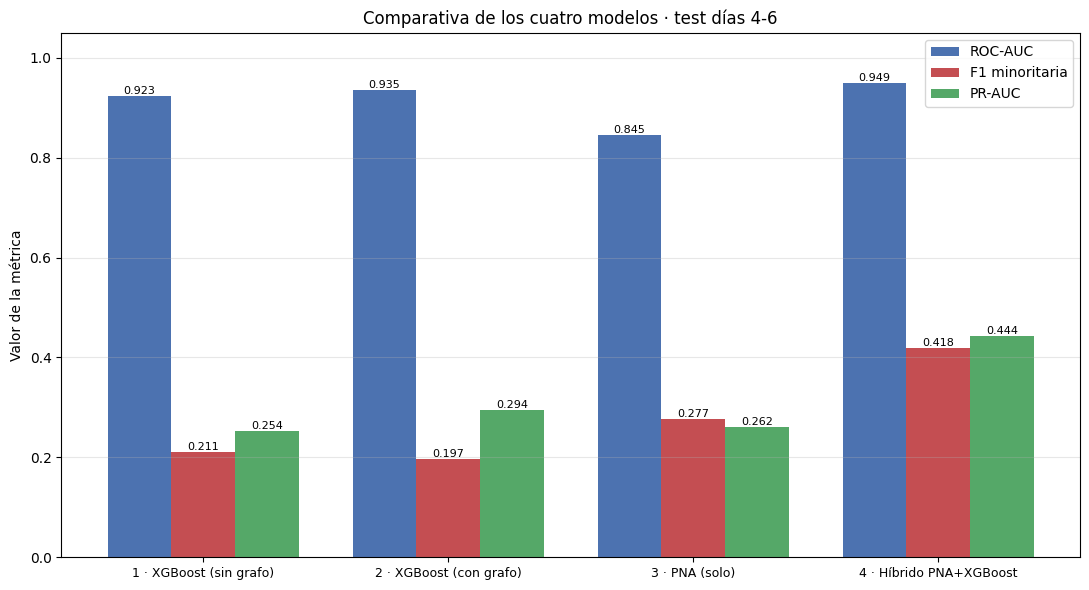

In [17]:
orden = ['1 · XGBoost (sin grafo)', '2 · XGBoost (con grafo)',
         '3 · PNA (solo)', '4 · Híbrido PNA+XGBoost']
tabla = pd.DataFrame(resultados).T.reindex(orden).round(4)
print(tabla.to_string())

tabla.to_csv('resultados_comparativa.csv', encoding='utf-8')

metricas = ['ROC-AUC', 'F1 minoritaria', 'PR-AUC']
colores = ['#4C72B0', '#C44E52', '#55A868']
x = np.arange(len(orden))
w = 0.26

fig, ax = plt.subplots(figsize=(11, 6))
for k, m in enumerate(metricas):
    barras = ax.bar(x + (k - 1) * w, tabla[m].values, w, label=m, color=colores[k])
    ax.bar_label(barras, fmt='%.3f', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(orden, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparativa de los cuatro modelos · test días 4-6')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparativa_4_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13 · Interpretabilidad del híbrido con SHAP

`TreeExplainer` descompone cada predicción en contribuciones aditivas por variable. El
interés metodológico reside en comparar la magnitud de los embeddings (`emb_0 … emb_15`)
con la de las variables explícitas: si los primeros figuran entre los más influyentes, la
red está codificando patrones estructurales que la ingeniería de variables manual no
logra capturar.



In [18]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(Xte)
print("Valores SHAP calculados:", shap_values.shape)

Valores SHAP calculados: (244221, 47)


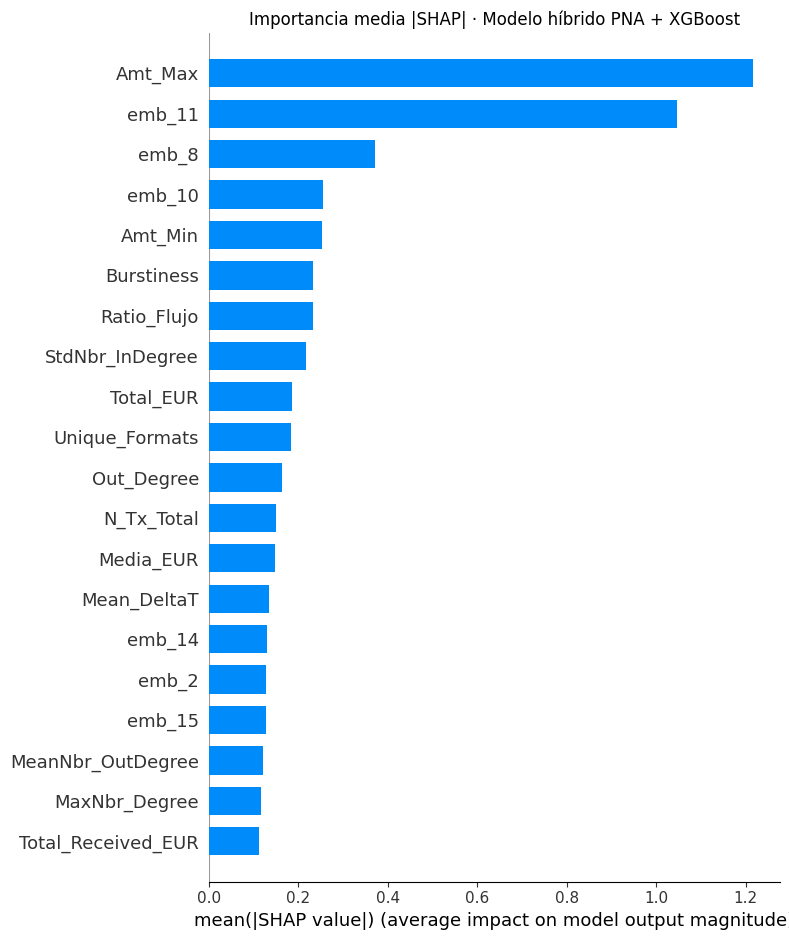

In [19]:
# Importancia media |SHAP| (gráfico de barras)
plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values, Xte, plot_type="bar", show=False, max_display=20)
plt.title("Importancia media |SHAP| · Modelo híbrido PNA + XGBoost")
plt.tight_layout()
plt.savefig('shap_importancia_barras.png', dpi=150, bbox_inches='tight')
plt.show()

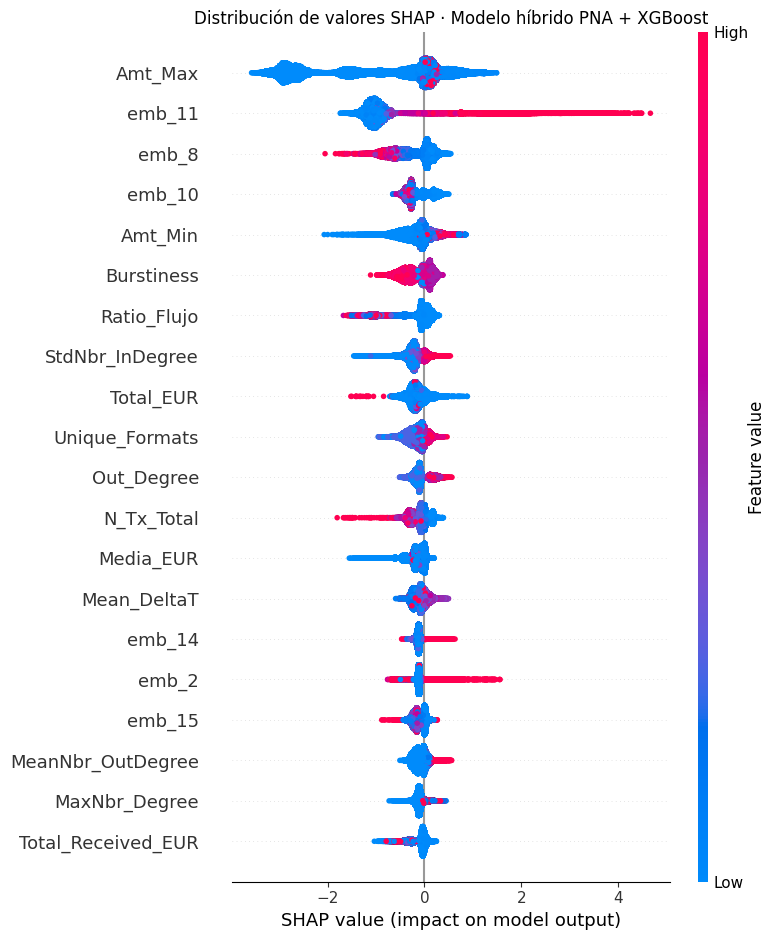

In [20]:
# Beeswarm: distribución de valores SHAP por variable.
# Cada punto es una cuenta; el color indica el valor de la variable (rojo alto,
# azul bajo) y la posición horizontal, su contribución al logit de fraude.
plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values, Xte, show=False, max_display=20)
plt.title("Distribución de valores SHAP · Modelo híbrido PNA + XGBoost")
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### Resumen numérico: peso relativo de los embeddings

Dato directamente citable en la sección de resultados: qué proporción de la importancia
total del modelo recae sobre las dimensiones aprendidas por la red neuronal de grafos.

In [21]:
imp_media = np.abs(shap_values).mean(axis=0)
resumen_shap = (pd.DataFrame({'Variable': Xte.columns, 'SHAP_medio': imp_media})
                .sort_values('SHAP_medio', ascending=False))

es_embedding = resumen_shap['Variable'].str.startswith('emb_')
peso_emb = (resumen_shap.loc[es_embedding, 'SHAP_medio'].sum()
            / resumen_shap['SHAP_medio'].sum())

print("15 variables más influyentes:")
print(resumen_shap.head(15).to_string(index=False))
print(f"\nProporción de la importancia total atribuible a los embeddings "
      f"de la PNA: {peso_emb*100:.1f}%")

resumen_shap.to_csv('resultados_shap.csv', index=False, encoding='utf-8')

15 variables más influyentes:
       Variable  SHAP_medio
        Amt_Max    1.215933
         emb_11    1.045665
          emb_8    0.370561
         emb_10    0.255783
        Amt_Min    0.252216
     Burstiness    0.232998
    Ratio_Flujo    0.232633
StdNbr_InDegree    0.218374
      Total_EUR    0.186455
 Unique_Formats    0.183412
     Out_Degree    0.163352
     N_Tx_Total    0.149344
      Media_EUR    0.147296
    Mean_DeltaT    0.134242
         emb_14    0.130304

Proporción de la importancia total atribuible a los embeddings de la PNA: 35.7%


---
## 14 · Lectura de los resultados

- La distancia entre los modelos **1 y 2** cuantifica la aportación de las variables
  estructurales explícitas; la distancia entre el **2 y el 4**, la de los embeddings de la
  PNA. Ambos saltos, junto con el modelo 3, sostienen la hipótesis central del trabajo.
- En el análisis SHAP, si los `emb_i` figuran entre las variables de mayor magnitud, la
  red está codificando patrones estructurales (ciclos, dispersión, vecindario) que las
  variables explícitas no capturan; si dominan las variables explícitas, los embeddings
  aportan un refinamiento marginal.

### Ficheros generados

| Fichero | Contenido |
|---------|-----------|
| `comparativa_4_modelos.png` | Gráfico de barras con las tres métricas |
| `shap_importancia_barras.png` | Importancia media \|SHAP\| del modelo híbrido |
| `shap_beeswarm.png` | Distribución de valores SHAP |
| `resultados_comparativa.csv` | Tabla numérica de métricas |
| `resultados_shap.csv` | Importancia SHAP de todas las variables |